In [2]:
import numpy as np
import pandas as pd


In [3]:
data=pd.read_excel("WA_Fn-UseC_-Telco-Customer-Churn.xlsx")
print(data.head())
print(data.info())
print(data.isnull().sum())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [4]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [5]:
data=data.dropna()
data=data.drop("customerID",axis=1)

data=pd.get_dummies(data,drop_first=True)

In [6]:
data.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes'],
      dtype='object')

In [7]:
data.astype(int)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29,29,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56,1889,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53,108,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42,1840,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70,151,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84,1990,1,1,1,1,0,1,...,1,0,1,1,0,1,0,0,1,0
7039,0,72,103,7362,0,1,1,1,0,1,...,1,0,1,1,0,1,1,0,0,0
7040,0,11,29,346,0,1,1,0,1,0,...,0,0,0,0,0,1,0,1,0,0
7041,1,4,74,306,1,1,0,1,0,1,...,0,0,0,0,0,1,0,0,1,1


In [8]:
X=data.drop("Churn_Yes",axis=1)
y=data["Churn_Yes"]
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=32)
scalar=StandardScaler()
X_train=scalar.fit_transform(X_train)
X_test=scalar.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=10000,class_weight='balanced')
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [10]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(X_test)
print(y_pred)
print("Accuracy : ",accuracy_score(y_test,y_pred))

[ True False  True ... False False False]
Accuracy :  0.749822316986496


In [11]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.91      0.73      0.81      1024
        True       0.53      0.80      0.63       383

    accuracy                           0.75      1407
   macro avg       0.72      0.77      0.72      1407
weighted avg       0.80      0.75      0.76      1407



In [12]:
y_prob=model.predict_proba(X_test)[:,1]
threshold=0.3
y_pred=(y_prob>=threshold).astype(int)
print("for 0.3 threshold in logisticresgression")
print(classification_report(y_true=y_test,y_pred=y_pred))
threshold=0.7
y_pred_2=(y_prob>=threshold).astype(int)
print("for 0.5 threshold in logisticresgression")
print(classification_report(y_true=y_test,y_pred=y_pred_2))

for 0.3 threshold in logisticresgression
              precision    recall  f1-score   support

       False       0.96      0.55      0.70      1024
        True       0.44      0.94      0.60       383

    accuracy                           0.66      1407
   macro avg       0.70      0.75      0.65      1407
weighted avg       0.82      0.66      0.67      1407

for 0.5 threshold in logisticresgression
              precision    recall  f1-score   support

       False       0.85      0.88      0.86      1024
        True       0.64      0.59      0.61       383

    accuracy                           0.80      1407
   macro avg       0.74      0.73      0.74      1407
weighted avg       0.79      0.80      0.79      1407



0.8520495063642297


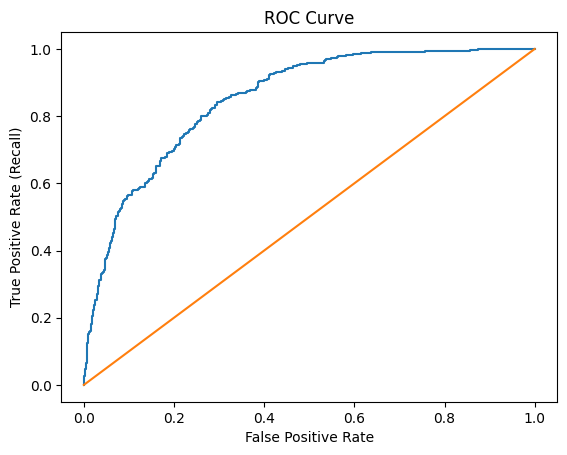

In [22]:
from sklearn.metrics import roc_curve,roc_auc_score
import matplotlib.pyplot as plt
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
score=roc_auc_score(y_test,y_prob)
print(score)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.show()

# print(f"tpr : {tpr} fpr  :  {fpr}   threasholds : {thresholds}")

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf=RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
print(classification_report(y_test,y_pred_rf))


              precision    recall  f1-score   support

       False       0.82      0.89      0.85      1024
        True       0.62      0.47      0.53       383

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.76      0.78      0.77      1407



                                 features  importance
3                            TotalCharges    0.196980
1                                  tenure    0.172067
2                          MonthlyCharges    0.167888
10            InternetService_Fiber optic    0.036117
28         PaymentMethod_Electronic check    0.032878
25                      Contract_Two year    0.030304
4                             gender_Male    0.028811
13                     OnlineSecurity_Yes    0.027567
26                   PaperlessBilling_Yes    0.026273
19                        TechSupport_Yes    0.024911
24                      Contract_One year    0.023658
5                             Partner_Yes    0.022983
0                           SeniorCitizen    0.021250
9                       MultipleLines_Yes    0.020999
15                       OnlineBackup_Yes    0.020474
6                          Dependents_Yes    0.019950
17                   DeviceProtection_Yes    0.019626
23                    Stream

<Axes: ylabel='features'>

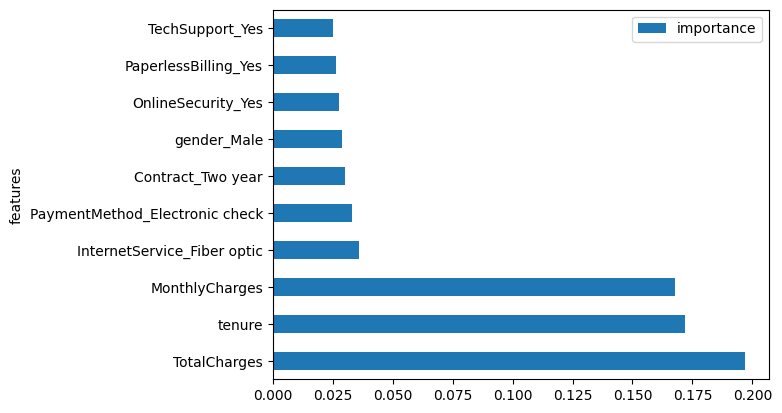

In [15]:
import pandas as pd
importance=rf.feature_importances_
columns=X.columns
feature_importance=pd.DataFrame({
    'features':columns,
    'importance':importance
})
feature_importance=feature_importance.sort_values(by='importance',ascending=False)
print(feature_importance)
import matplotlib.pyplot as plt
feature_importance.head(10).plot(x='features',y='importance',kind='barh')

In [16]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
dtc_1=DecisionTreeClassifier(max_depth=3)
dtc_2=DecisionTreeClassifier(max_depth=5)
dtc_3=DecisionTreeClassifier(max_depth=10)

dtc_1=dtc_1.fit(X_train,y_train)
y_pred=dtc_1.predict(X_test)
print(classification_report(y_true=y_test,y_pred=y_pred))


              precision    recall  f1-score   support

       False       0.81      0.94      0.87      1024
        True       0.71      0.42      0.52       383

    accuracy                           0.79      1407
   macro avg       0.76      0.68      0.70      1407
weighted avg       0.78      0.79      0.77      1407



In [17]:
dtc_2=dtc_2.fit(X_train,y_train)
y_pred=dtc_2.predict(X_test)
print(classification_report(y_true=y_test,y_pred=y_pred))

              precision    recall  f1-score   support

       False       0.82      0.91      0.86      1024
        True       0.66      0.48      0.55       383

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [18]:
dtc_3=dtc_3.fit(X_train,y_train)
y_pred=dtc_3.predict(X_test)
print(classification_report(y_true=y_test,y_pred=y_pred))

              precision    recall  f1-score   support

       False       0.82      0.85      0.84      1024
        True       0.56      0.50      0.53       383

    accuracy                           0.76      1407
   macro avg       0.69      0.68      0.68      1407
weighted avg       0.75      0.76      0.75      1407



In [19]:
y_prob = model.predict_proba(X_test)[:, 1]
y_prob

array([0.53065066, 0.02426369, 0.7686695 , ..., 0.32439281, 0.03991492,
       0.32747405], shape=(1407,))

In [20]:
import numpy as np

threshold = 0.3
y_pred_new = (y_prob >= threshold).astype(int)
y_pred_new

array([1, 0, 1, ..., 1, 0, 1], shape=(1407,))

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

       False       0.96      0.55      0.70      1024
        True       0.44      0.94      0.60       383

    accuracy                           0.66      1407
   macro avg       0.70      0.75      0.65      1407
weighted avg       0.82      0.66      0.67      1407

